# Run a Batch Experiment for Several Values of alpha

### Setup

In [1]:
from pathlib import Path
import numpy as np

from msean import load_config
from msean.measurements.batch import batch_experiment
from msean.measurements.properties import PropertyEnum

Load global configuration from file <b>configs/default.yaml</b>.

In [2]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default_normal.yaml")
runs_dir = root / "runs"

Intialize random number generator for experiment reproducibility.

In [3]:
rng = np.random.default_rng(cfg.seed)

### Run Batch Experiment

In [4]:
alpha_list = [(1/2)**(i/2) for i in range(0, 16)]

In [5]:
results, paths = batch_experiment(
        cfg=cfg,
        parent_dir=runs_dir,
        rng=rng,
        param_name="connection.alpha",
        param_values=alpha_list,
        properties=[
            PropertyEnum.AVERAGE_DEGREE,
            PropertyEnum.AVERAGE_DEGREE_PER_LAYER,
            PropertyEnum.DENSITY,
            PropertyEnum.DENSITY_PER_LAYER,
            PropertyEnum.AVERAGE_LOCAL_CLUSTERING,
            PropertyEnum.DEGREE_DISTRIBUTION,
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER,
            PropertyEnum.TRIANGLES,
            PropertyEnum.TRIANGLES_PER_LAYER,
            PropertyEnum.TRIANGLE_DIMENSIONS,
            #PropertyEnum.EMBEDDEDNESS_DISTRIBUTION,
            PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION,
            PropertyEnum.GLOBAL_CLUSTERING,
            PropertyEnum.EDGE_LENGTH_DISTRIBUTION
        ],
    )

Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes with normal distribution
Embedding nodes 

### Property Analysis

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as clr
import numpy as np

alphas = alpha_list
plot_dir = paths["batch_dir"] / "plots"

linestyles = ["-"]#, "--", "-.", ":"]

cmap = cm.viridis

norm = clr.SymLogNorm(
    linthresh=1e-3,
    vmin=min(alphas),
    vmax=max(alphas),
    base=2,
)

tick_is = list(range(0, 21, 2))
ticks = [(1/2)**(i/2) for i in tick_is]

log_ticks = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

In [7]:
prop_labels = {
    PropertyEnum.TRIANGLES: r"Number of triangles ($\tau$)",
    PropertyEnum.TRIANGLES_PER_LAYER: r"Number of triangles for layer ($\tau^\ell$)",
    PropertyEnum.AVERAGE_DEGREE: r"Average degree ($\kappa$)",
    PropertyEnum.AVERAGE_DEGREE_PER_LAYER: r"Average degree for layer ($\kappa^\ell$)",
    PropertyEnum.DENSITY: r"Density ($\rho$)",
    PropertyEnum.DENSITY_PER_LAYER: r"Density for layer ($\rho^\ell$)",
    PropertyEnum.DEGREE_DISTRIBUTION: rf"Degree ($\mathit{{k}}$)",
    PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER: rf"Degree ($\mathit{{k}}$)",
    #PropertyEnum.EMBEDDEDNESS_DISTRIBUTION: "Embededdness",
    PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION: rf"Local clustering coefficient ($\mathit{{c}}$)",
    PropertyEnum.AVERAGE_LOCAL_CLUSTERING: rf"Average local clustering coefficient ($\bar{{c}}$)",
    PropertyEnum.GLOBAL_CLUSTERING: rf"Global clustering coefficient ($\mathit{{C}}$)",
    PropertyEnum.EDGE_LENGTH_DISTRIBUTION: "Edge length",
}

alpha_label = r"Spatial freedom ($\alpha$)"

### Global Scalar Properties

average_degree vs alpha


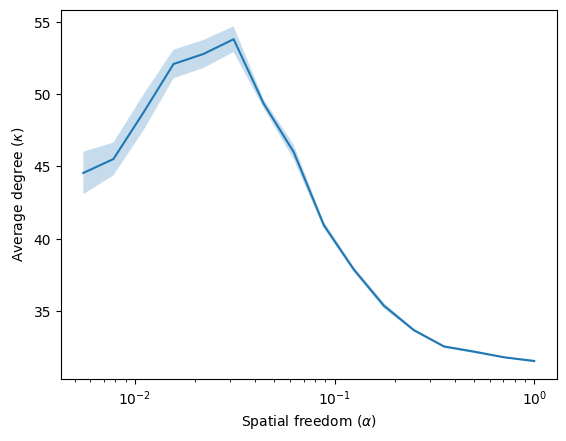

density vs alpha


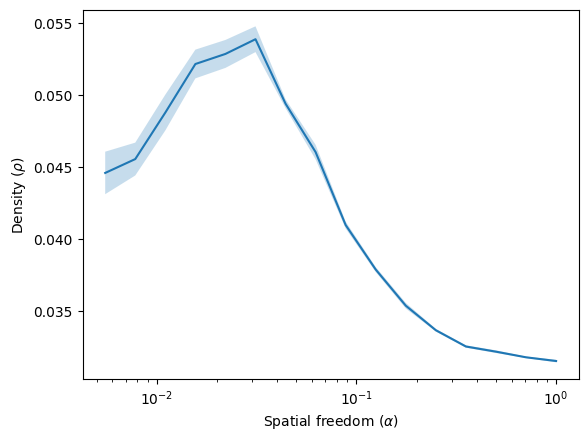

average_local_clustering vs alpha


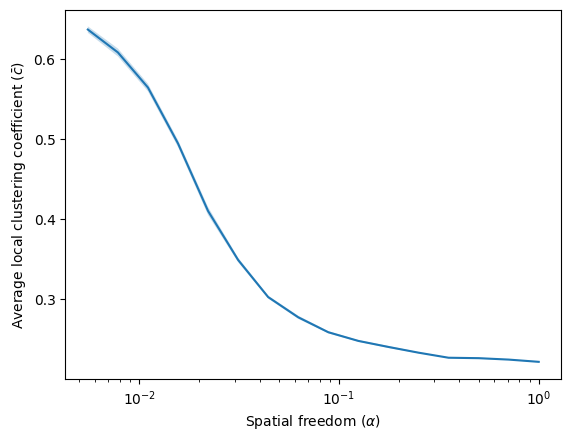

global_clustering vs alpha


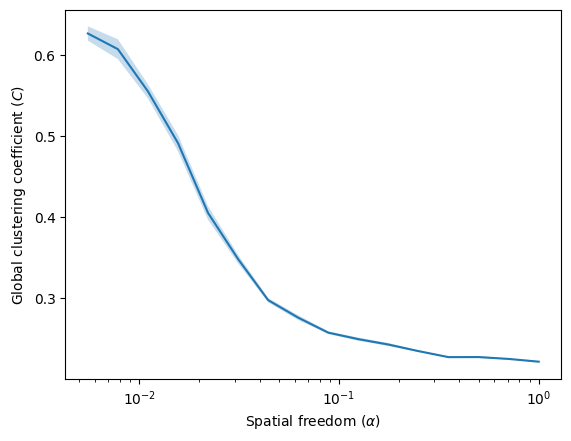

triangles vs alpha


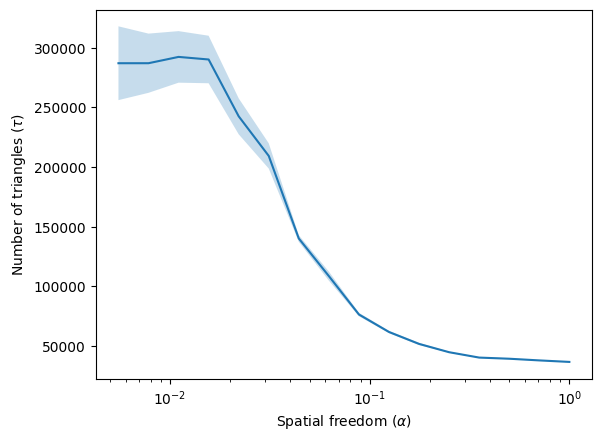

In [8]:
global_props = [
    PropertyEnum.AVERAGE_DEGREE,
    PropertyEnum.DENSITY,
    PropertyEnum.AVERAGE_LOCAL_CLUSTERING,
    PropertyEnum.GLOBAL_CLUSTERING,
    PropertyEnum.TRIANGLES,
]

for prop in global_props:
    print(f"{prop.name.lower()} vs alpha")

    means = np.array([results[a][prop][0] for a in alphas])
    #stds = np.array([results[a][prop][1] for a in alphas])
    ses = np.array([results[a][prop][2] for a in alphas])

    fig, ax = plt.subplots()

    ax.plot(alphas, means)

    ax.fill_between(
        alphas,
        means - ses, #stds,
        means + ses, #stds,
        alpha=0.25,
    )

    #ax.set_title(f"{label} vs {alpha_label}")
    ax.set_xscale("log")
    ax.set_xlabel(alpha_label)

    label = prop_labels.get(prop, prop.name.lower())
    ax.set_ylabel(label)

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_vs_alpha_log.png",
        bbox_inches="tight",
    )

    plt.show()

### Per-layer Global Properties

average_degree_per_layer vs alpha


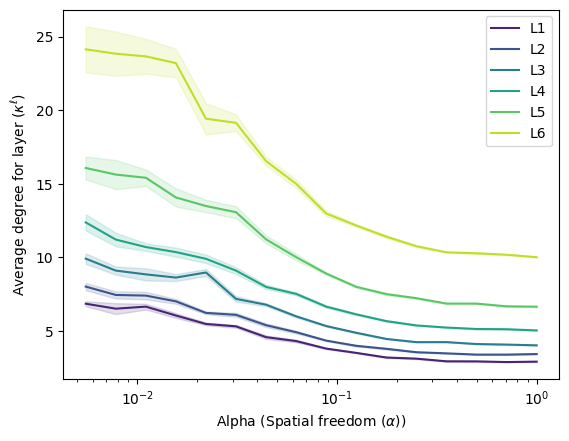

density_per_layer vs alpha


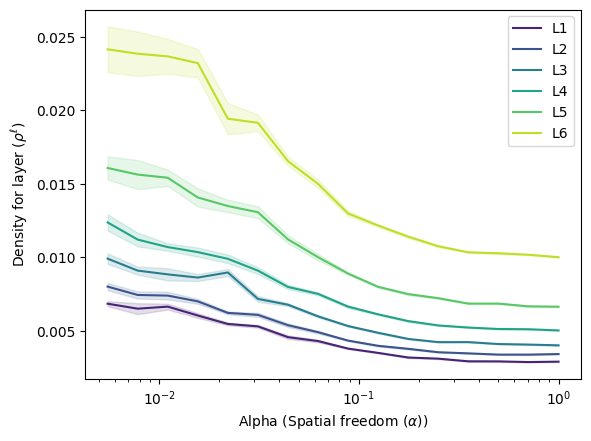

triangles_per_layer vs alpha


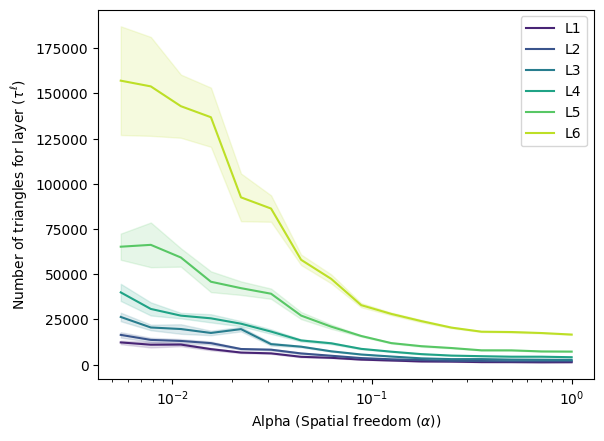

In [9]:
per_layer_props = [
    PropertyEnum.AVERAGE_DEGREE_PER_LAYER,
    PropertyEnum.DENSITY_PER_LAYER,
    PropertyEnum.TRIANGLES_PER_LAYER
]

layer_colors = plt.cm.viridis(
    np.linspace(0.1, 0.9, len(cfg.network.layer_labels))
)

for prop in per_layer_props:
    print(f"{prop.name.lower()} vs alpha")

    fig, ax = plt.subplots()

    for j, label in enumerate(cfg.network.layer_labels):

        means = np.array([results[a][prop][0][j] for a in alphas])
        #stds = np.array([results[a][prop][1][j] for a in alphas])
        ses = np.array([results[a][prop][2][j] for a in alphas])

        ax.plot(
            alphas,
            means,
            color=layer_colors[j],
            linestyle=linestyles[j % len(linestyles)],
            label=label,
        )

        ax.fill_between(
            alphas,
            means - ses, #stds,
            means + ses, #stds,
            color=layer_colors[j],
            alpha=0.15,
        )

    #ax.set_title(f"{label} vs {alpha_label} by layer")
    ax.set_xscale("log")
    ax.set_xlabel(f"Alpha ({alpha_label})")
    
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_ylabel(label)

    ax.legend()

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_vs_alpha_by_layer_log.png",
        bbox_inches="tight",
    )

    plt.show()

### Distribution Properties

degree_distribution across alpha values


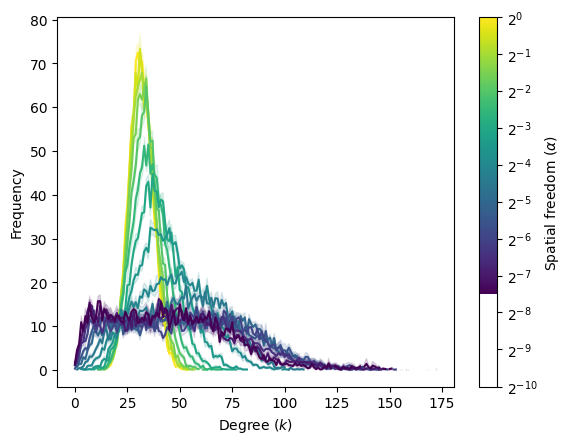

local_clustering_distribution across alpha values


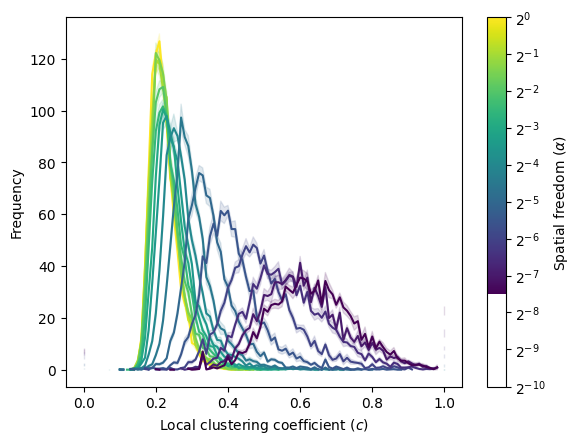

edge_length_distribution across alpha values


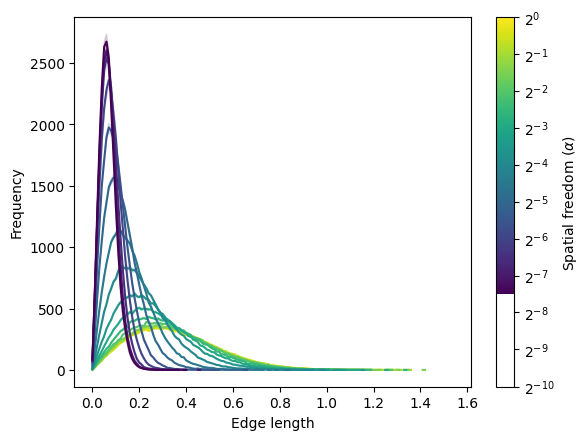

In [10]:
distribution_props = [
    PropertyEnum.DEGREE_DISTRIBUTION,
    # PropertyEnum.EMBEDDEDNESS_DISTRIBUTION,
    PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION,
    PropertyEnum.EDGE_LENGTH_DISTRIBUTION,
]

for prop in distribution_props:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        dist = results[alpha][prop]

        x = dist[:, 0]
        y = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = 0
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([
        rf"$2^{{{-i//2}}}$"
        for i in tick_is
    ])

    label = prop_labels.get(prop, prop.name.lower())

    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

In [11]:
def rebin_degree_distribution(x, y, se, bin_width=5):
    x = np.asarray(x)
    y = np.asarray(y)
    se = np.asarray(se)

    bin_id = (x // bin_width).astype(int)

    x_binned = []
    y_binned = []
    se_binned = []

    for b in np.unique(bin_id):
        mask = bin_id == b

        x_binned.append(np.mean(x[mask]))
        y_binned.append(np.nansum(y[mask]))
        se_binned.append(np.sqrt(np.nansum(se[mask] ** 2)))

    return np.array(x_binned), np.array(y_binned), np.array(se_binned)

degree_distribution across alpha values


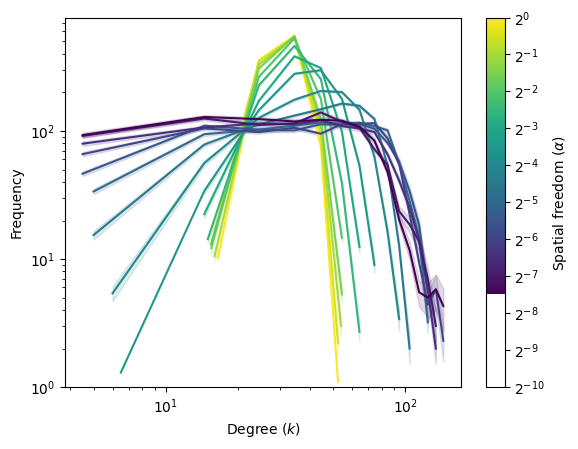

In [12]:
distribution_props = [
    PropertyEnum.DEGREE_DISTRIBUTION
]

for prop in distribution_props:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        dist = results[alpha][prop]

        x = dist[:, 0]
        y = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        x, y, se = rebin_degree_distribution(
            x,
            y,
            se,
            bin_width=10,
        )

        lower = y - se
        upper = y + se

        y[y <= 1] = np.nan
        lower[lower <= 1] = np.nan
        upper[upper <= 1] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([
        rf"$2^{{{-i//2}}}$"
        for i in tick_is
    ])

    label = prop_labels.get(prop, prop.name.lower())

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(1, plt.ylim()[1])

    #ax.set_xticks(log_ticks)
    #ax.set_yticks(log_ticks)

    #ax.set_xticklabels([str(t) for t in log_ticks])
    #ax.set_yticklabels([str(t) for t in log_ticks])

    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha_binned_10_log.png",
        bbox_inches="tight",
    )

    plt.show()

### Distributions with bins of size 5

degree_distribution across alpha values


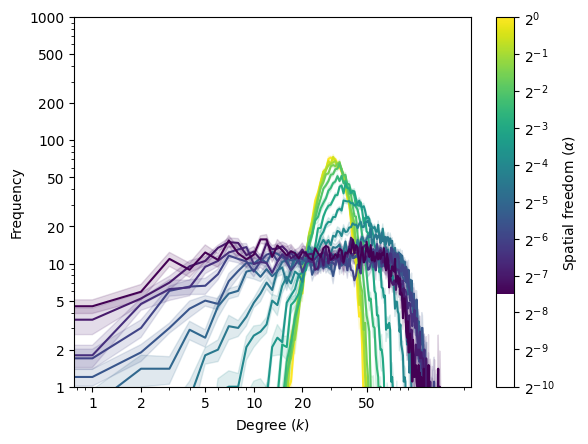

In [13]:
distribution_props_log = [
    PropertyEnum.DEGREE_DISTRIBUTION
]

for prop in distribution_props_log:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        dist = results[alpha][prop]

        x = dist[:, 0]
        y = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{{-i//2}}}$"
        for i in tick_is
    ])

    label = prop_labels.get(prop, prop.name.lower())

    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(1, plt.ylim()[1])

    ax.set_xticks(log_ticks[:-4])
    ax.set_yticks(log_ticks)

    ax.set_xticklabels([str(t) for t in log_ticks[:-4]])
    ax.set_yticklabels([str(t) for t in log_ticks])

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha_log.png",
        bbox_inches="tight",
    )

    plt.show()

### Degree Distribution Per Layer

degree_distribution for layer L1 (350) across alpha


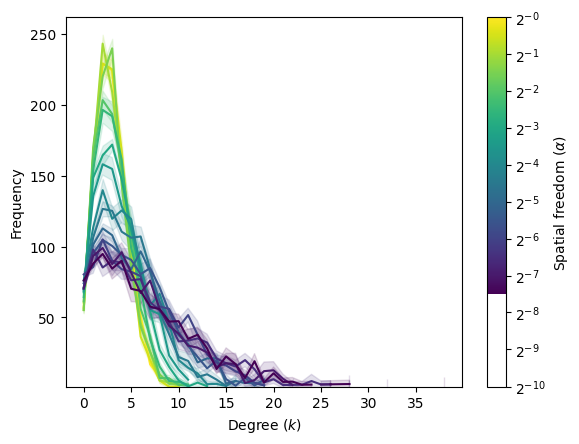

degree_distribution for layer L2 (300) across alpha


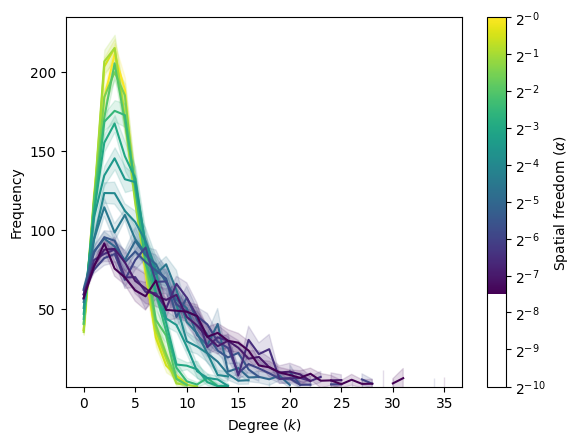

degree_distribution for layer L3 (250) across alpha


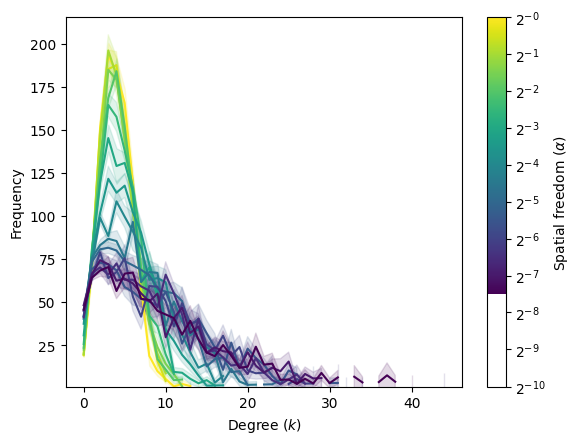

degree_distribution for layer L4 (200) across alpha


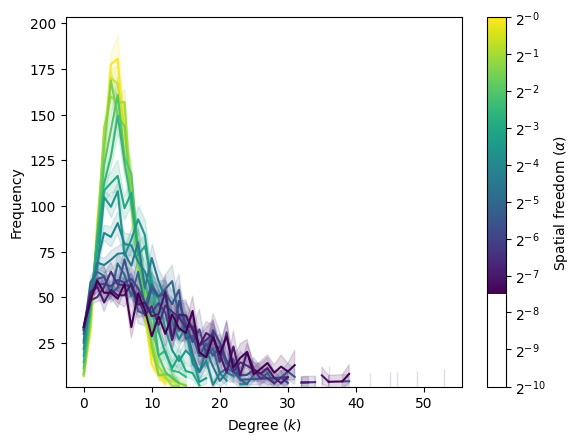

degree_distribution for layer L5 (150) across alpha


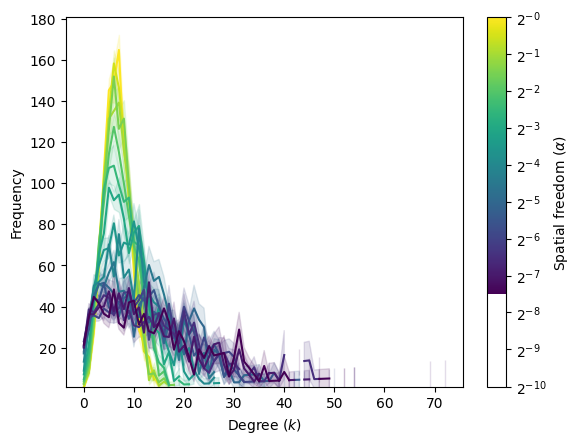

degree_distribution for layer L6 (100) across alpha


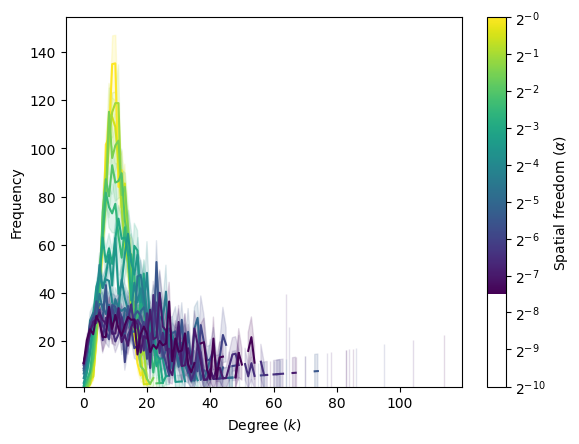

In [15]:
layer_sizes = [350, 300, 250, 200, 150, 100]

for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 21, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    ax.set_ylim(bottom=1)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer L1 (350) across alpha


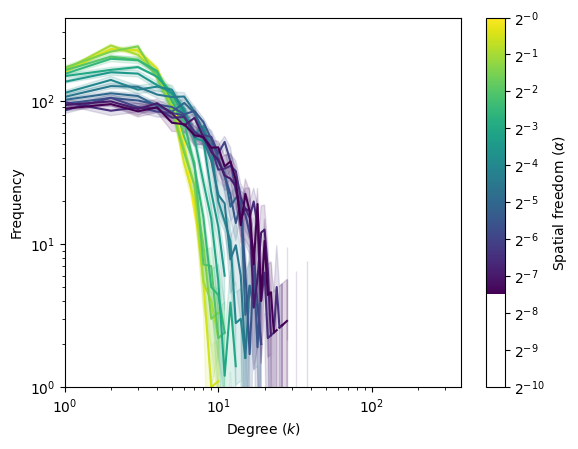

degree_distribution for layer L2 (300) across alpha


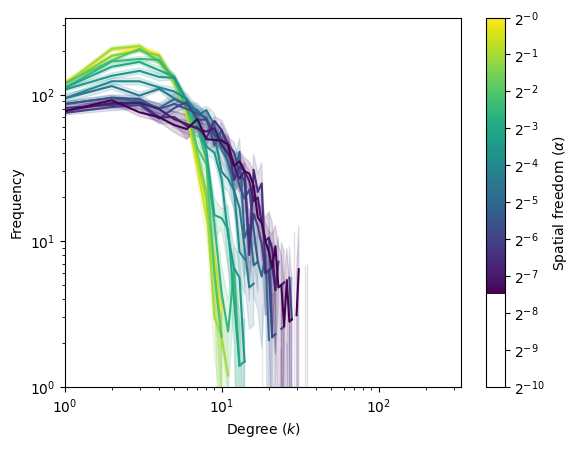

degree_distribution for layer L3 (250) across alpha


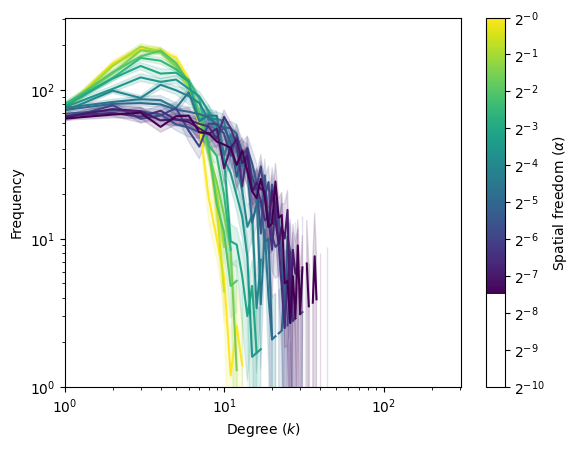

degree_distribution for layer L4 (200) across alpha


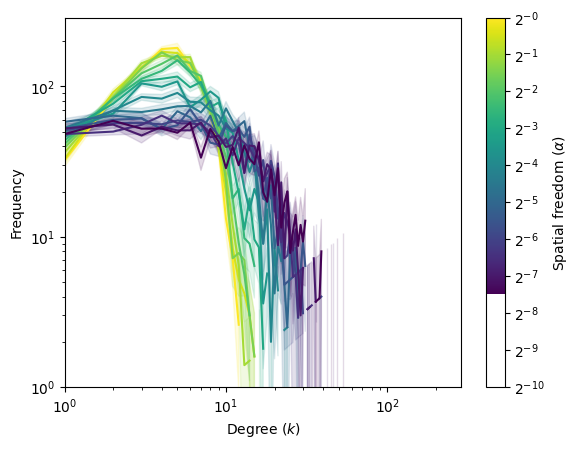

degree_distribution for layer L5 (150) across alpha


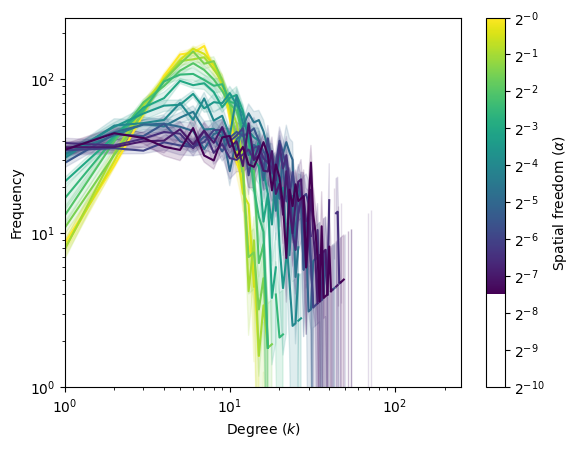

degree_distribution for layer L6 (100) across alpha


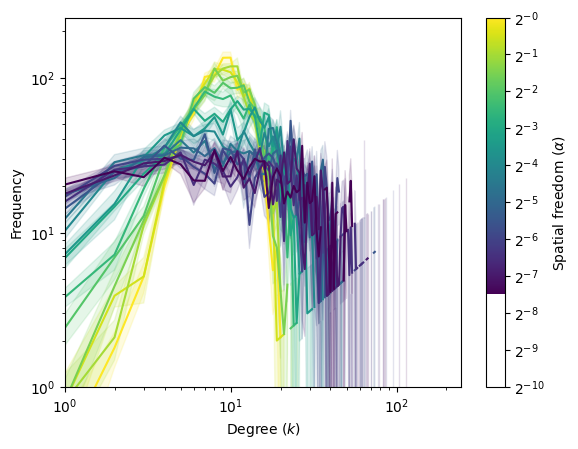

In [16]:
for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 21, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(1, plt.ylim()[1])
    ax.set_xlim(1, plt.ylim()[1])

    #ax.set_xticks(log_ticks)
    #ax.set_yticks(log_ticks)

    #ax.set_xticklabels([str(t) for t in log_ticks])
    #ax.set_yticklabels([str(t) for t in log_ticks])

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_log.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer L1 (350) across alpha


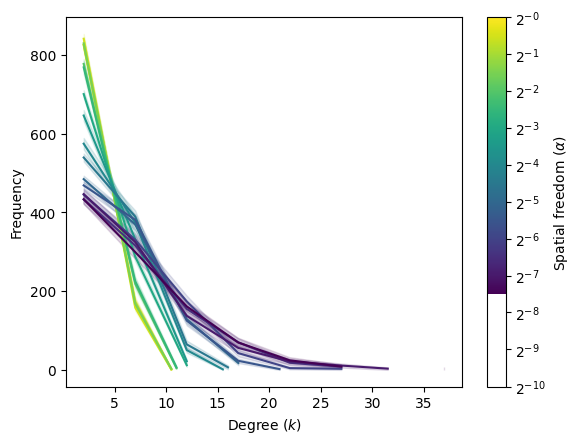

degree_distribution for layer L2 (300) across alpha


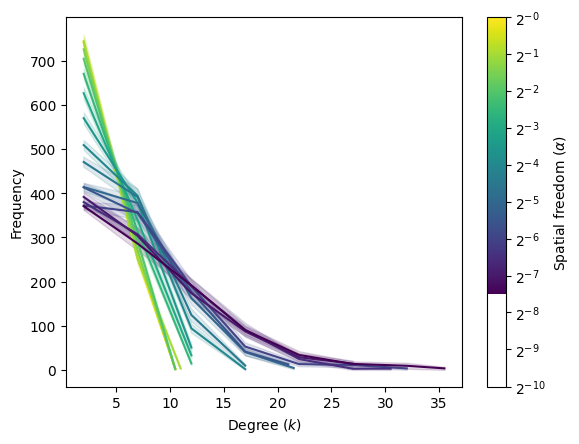

degree_distribution for layer L3 (250) across alpha


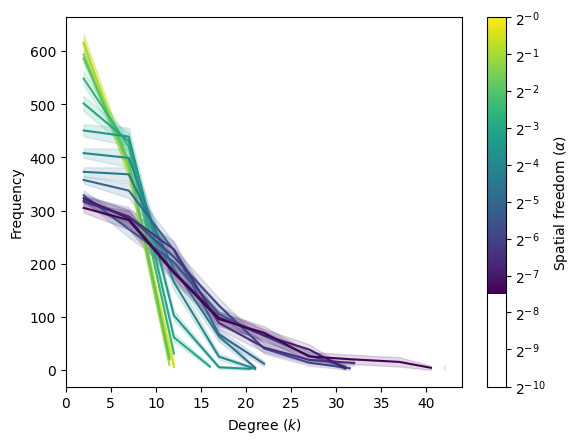

degree_distribution for layer L4 (200) across alpha


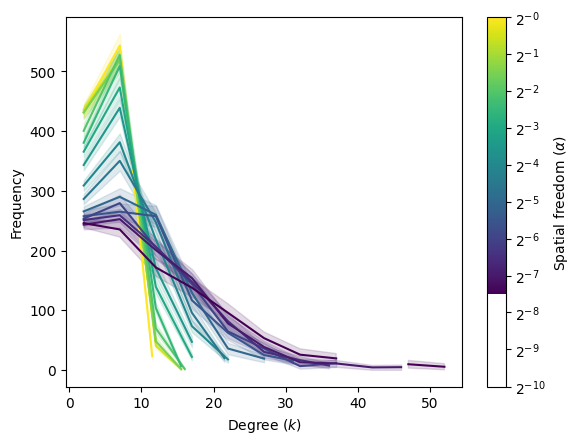

degree_distribution for layer L5 (150) across alpha


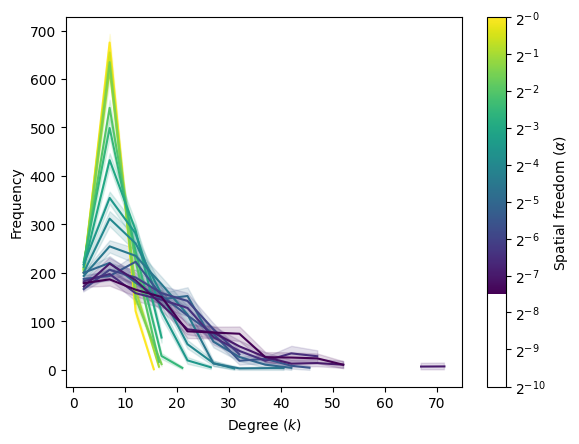

degree_distribution for layer L6 (100) across alpha


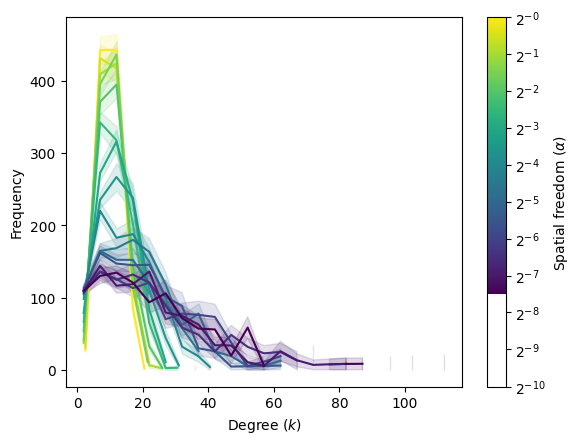

In [18]:
layer_sizes = [350, 300, 250, 200, 150, 100]
bin_width = 5

for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        k, freq, se = rebin_degree_distribution(
            k,
            freq,
            se,
            bin_width=bin_width,
        )

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 21, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")

    #ax.set_xscale("log")
    #ax.set_yscale("log")
    #ax.set_ylim(1, plt.ylim()[1])
    #ax.set_xlim(1, plt.ylim()[1])

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_binned_{bin_width}.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution by layer (alpha=1.0)


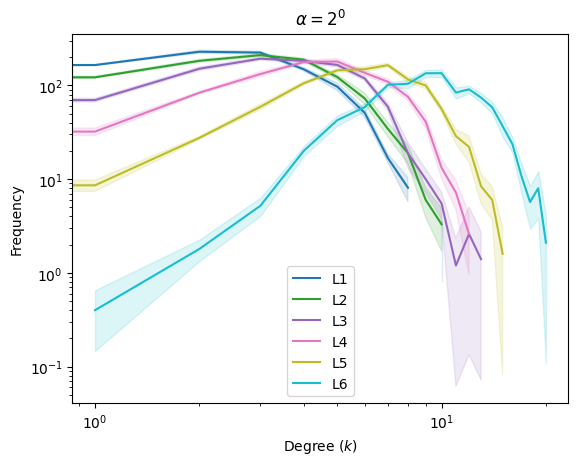

degree_distribution by layer (alpha=0.7071067811865476)


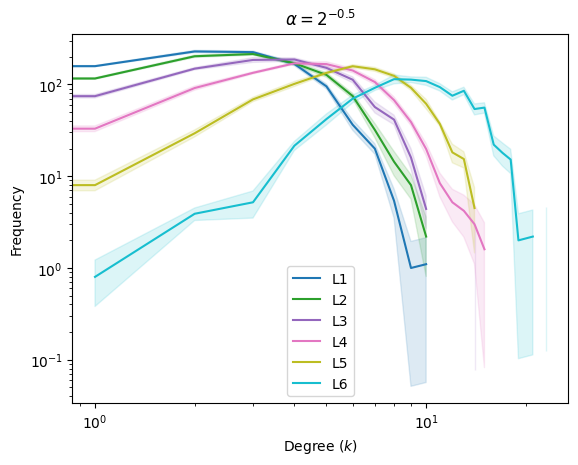

degree_distribution by layer (alpha=0.5)


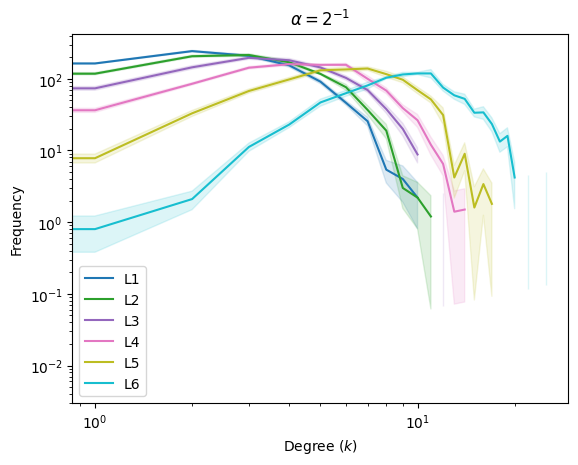

degree_distribution by layer (alpha=0.3535533905932738)


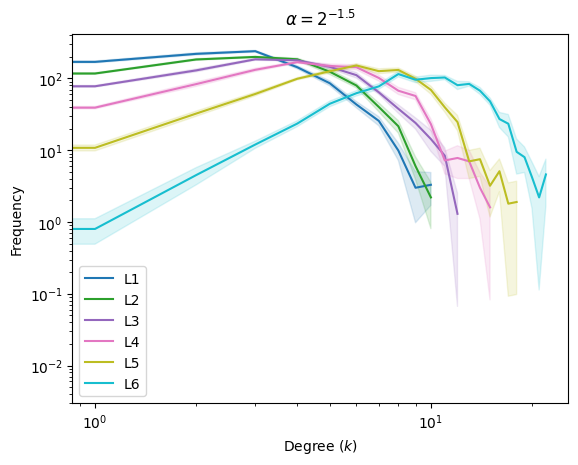

degree_distribution by layer (alpha=0.25)


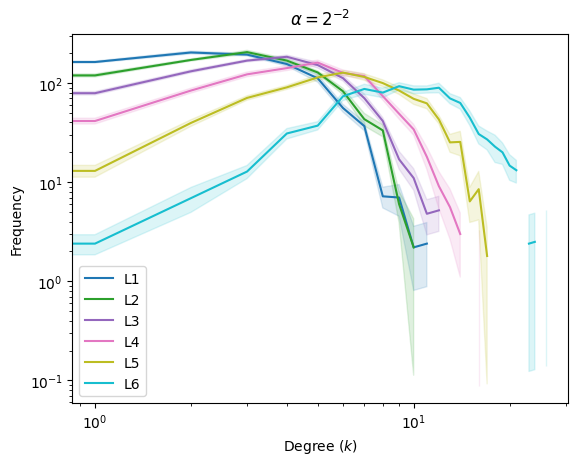

degree_distribution by layer (alpha=0.1767766952966369)


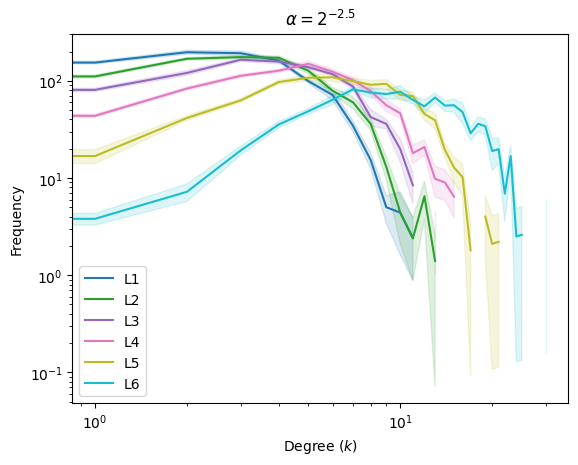

degree_distribution by layer (alpha=0.125)


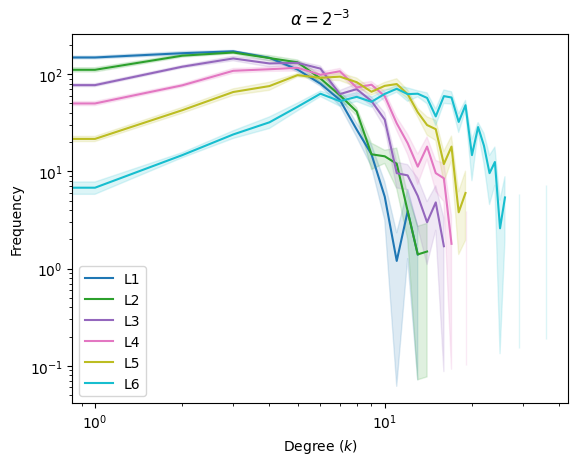

degree_distribution by layer (alpha=0.08838834764831845)


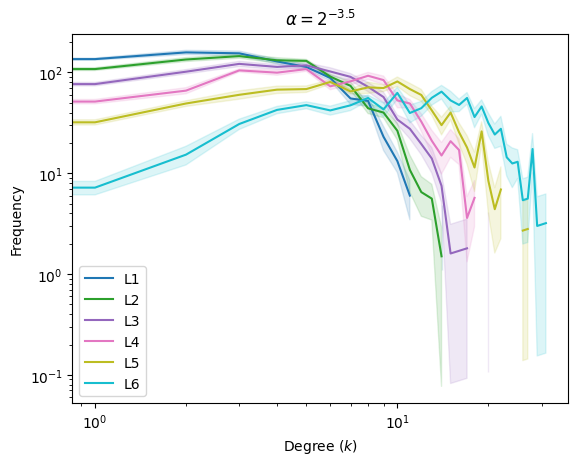

degree_distribution by layer (alpha=0.0625)


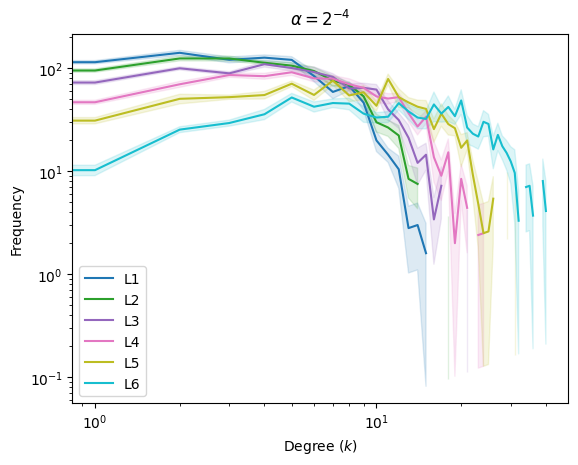

degree_distribution by layer (alpha=0.04419417382415922)


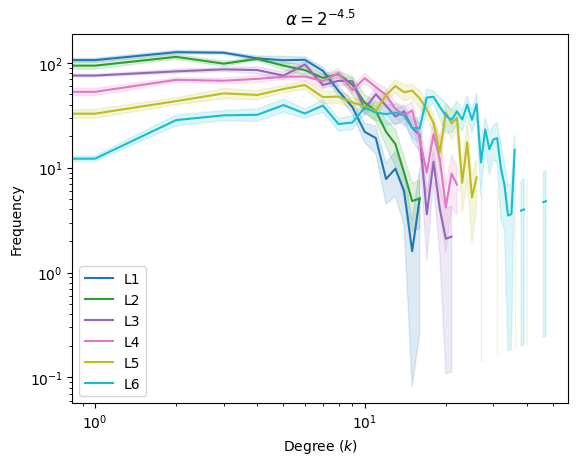

degree_distribution by layer (alpha=0.03125)


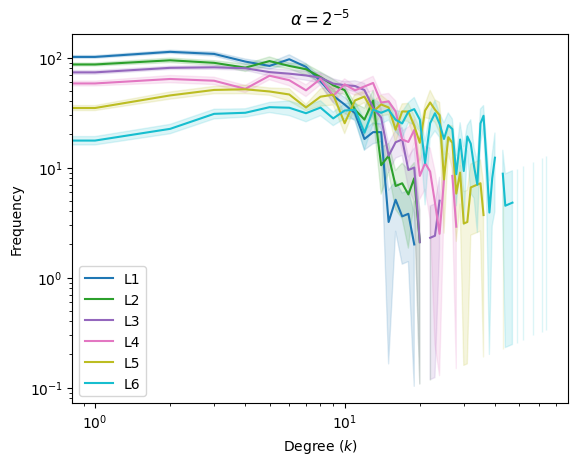

degree_distribution by layer (alpha=0.02209708691207961)


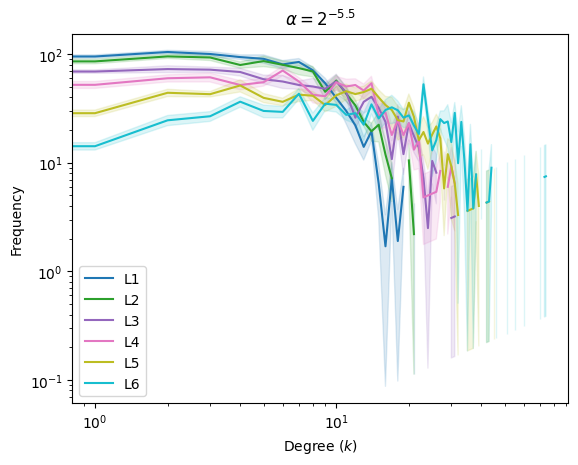

degree_distribution by layer (alpha=0.015625)


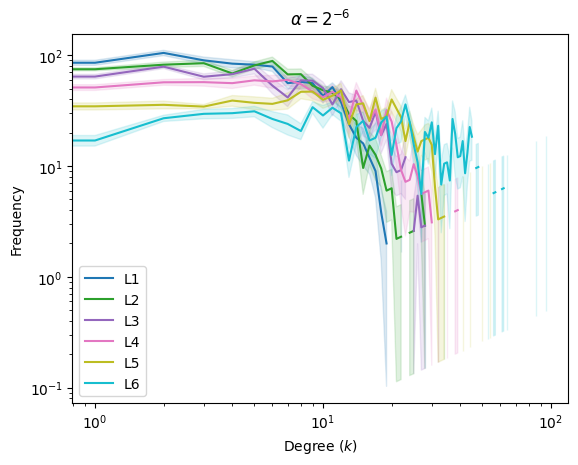

degree_distribution by layer (alpha=0.011048543456039806)


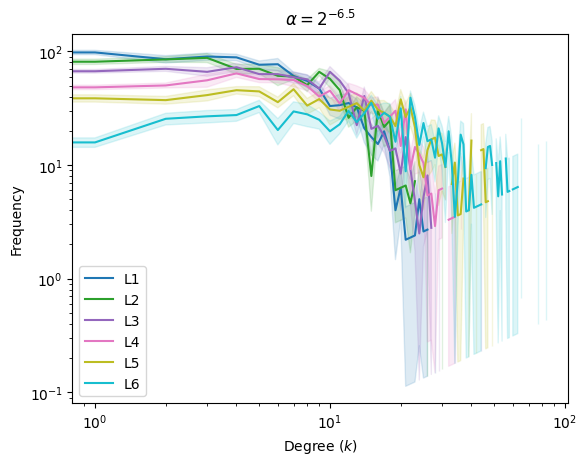

degree_distribution by layer (alpha=0.0078125)


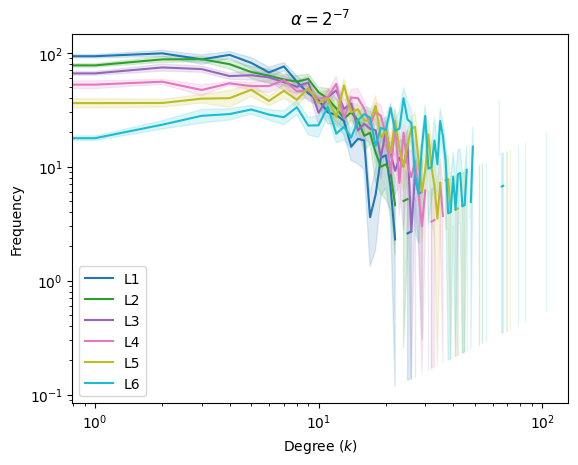

degree_distribution by layer (alpha=0.005524271728019903)


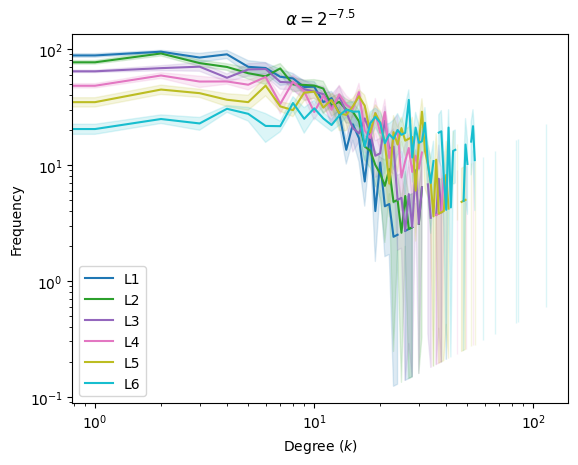

In [19]:
layer_colors = plt.cm.tab10(
    np.linspace(0, 1, len(cfg.network.layer_labels))
)

for alpha_idx, alpha in enumerate(alphas):

    print(
        f"degree_distribution by layer "
        f"(alpha={alpha})"
    )

    fig, ax = plt.subplots()

    deg_dists_layers = results[alpha][
        PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
    ]

    for layer_idx, layer_label in enumerate(
        cfg.network.layer_labels
    ):

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        """ax.plot(
            k,
            freq,
            color=layer_colors[layer_idx],
            linewidth=0.5,
            alpha=0.5,
        )

        ax.scatter(
            k,
            freq,
            color=layer_colors[layer_idx],
            s=15,
            label=(
                f"{layer_label} "
                f"({layer_sizes[layer_idx]})"
            ),
        )"""

        ax.plot(
            k,
            freq,
            color=layer_colors[layer_idx],
            linestyle=linestyles[
                layer_idx % len(linestyles)
            ],
            label=f"{layer_label}"
        )

        ax.fill_between(
            k,
            lower,
            upper,
            color=layer_colors[layer_idx],
            alpha=0.15,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.set_xlim(1, plt.ylim()[1])
    #ax.set_ylim(1, plt.ylim()[1])

    #ax.set_xticks(log_ticks[:-4])
    #ax.set_yticks(log_ticks)

    #ax.set_xticklabels([str(t) for t in log_ticks[:-4]])
    #ax.set_yticklabels([str(t) for t in log_ticks])

    ax.set_xlabel(r"Degree ($\mathit{k}$)")
    ax.set_ylabel("Frequency")

    ax.legend()

    exponent = (-alpha_idx) / 2
    ax.set_title(
        rf"$\alpha = 2^{{{exponent:g}}}$"
    )

    plt.savefig(
        plot_dir /
        f"degree_distribution_layers_alpha_2^{exponent:g}.png",
        bbox_inches="tight",
    )

    plt.show()

### Triangle dimensions

1d triangles


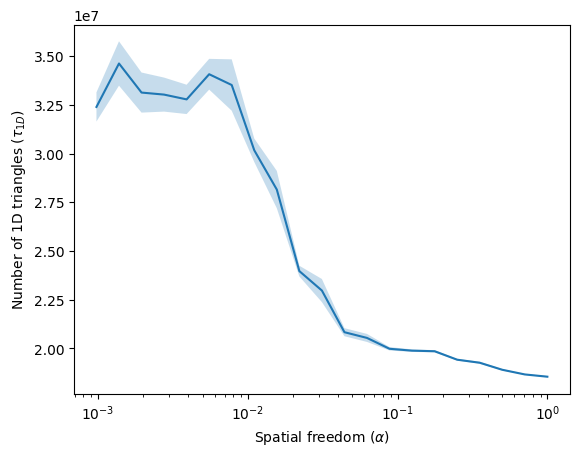

2d triangles


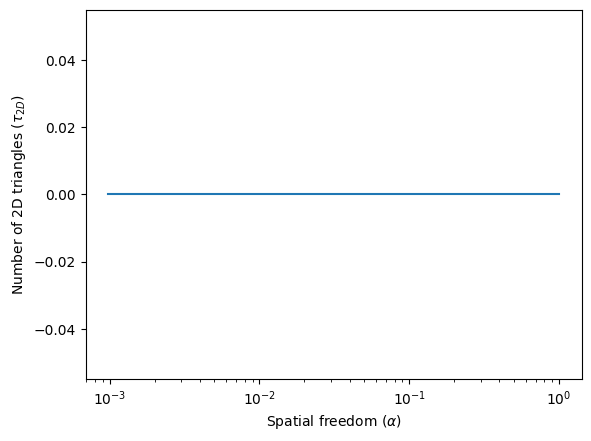

3d triangles


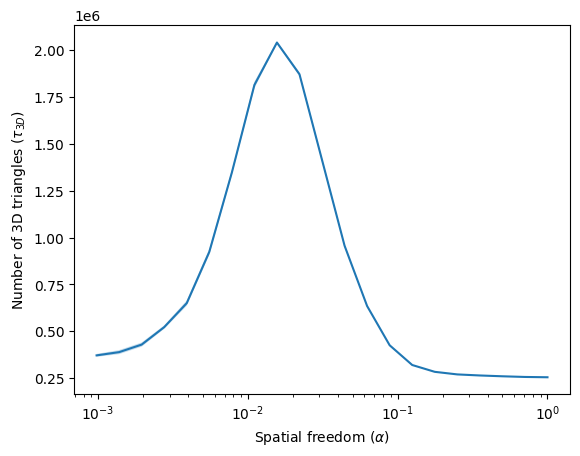

In [ ]:
dimension_labels = [
    r"Number of 1D triangles ($\tau_{1D}$)",
    r"Number of 2D triangles ($\tau_{2D}$)",
    r"Number of 3D triangles ($\tau_{3D}$)",
]

dimension_names = ["1d", "2d", "3d"]

for dim_idx, (dim_label, dim_name) in enumerate(
    zip(dimension_labels, dimension_names)
):
    print(f"{dimension_names[dim_idx]} triangles")
    fig, ax = plt.subplots()

    means = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][dim_idx]
        for a in alphas
    ])

    ses = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][dim_idx]
        for a in alphas
    ])

    ax.plot(
        alphas,
        means,
    )

    ax.fill_between(
        alphas,
        means - ses,
        means + ses,
        alpha=0.25,
    )

    ax.set_xscale("log")
    ax.set_xlabel(alpha_label)
    ax.set_ylabel(dim_label)

    plt.savefig(
        plot_dir / f"triangles_{dim_name}_vs_alpha_se_log.png",
        bbox_inches="tight",
    )

    plt.show()

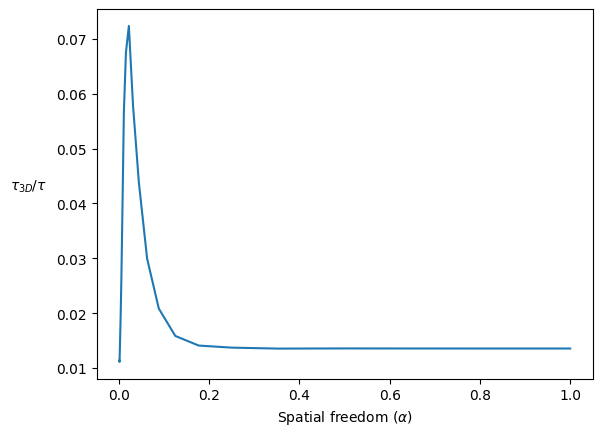

In [ ]:
fig, ax = plt.subplots()

ratio_means = []
ratio_ses = []

for alpha in alphas:

    mean_dims, std_dims, se_dims = results[alpha][
        PropertyEnum.TRIANGLE_DIMENSIONS
    ]

    tau_1d, tau_2d, tau_3d = mean_dims
    se_1d, se_2d, se_3d = se_dims

    tau_total = tau_1d + tau_2d + tau_3d
    se_total = se_1d + se_2d + se_3d

    if tau_total > 0:
        ratio_mean = tau_3d / tau_total

        ratio_se = (
            (tau_3d + se_3d) / (tau_total + se_total)
            - ratio_mean
        )

        ratio_means.append(ratio_mean)
        ratio_ses.append(abs(ratio_se))
    else:
        ratio_means.append(np.nan)
        ratio_ses.append(np.nan)

ratio_means = np.array(ratio_means)
ratio_ses = np.array(ratio_ses)

ax.plot(
    alphas,
    ratio_means,
)

"""ax.fill_between(
    alphas,
    ratio_means - ratio_ses,
    ratio_means + ratio_ses,
    alpha=0.25,
)"""

#ax.set_xscale("log")
ax.set_xlabel(alpha_label)
ax.set_ylabel(
    r"$\tau_{3D}/\tau$",
    rotation=0,
    labelpad=20,
)

plt.savefig(
    plot_dir / "triangle_3d_fraction_vs_alpha.png",
    bbox_inches="tight",
)

plt.show()

### Graphs with Smoothing

In [ ]:
!pip install scipy


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


degree_distribution across alpha values


ValueError: too many values to unpack (expected 3)

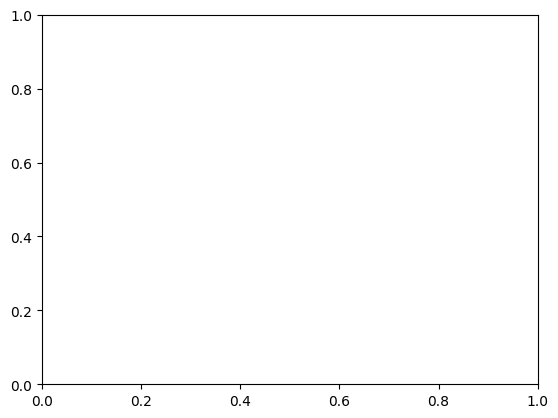

In [ ]:
from scipy.ndimage import gaussian_filter1d

smooth_props = [
    PropertyEnum.DEGREE_DISTRIBUTION,
    PropertyEnum.EMBEDDEDNESS_DISTRIBUTION,
]

for prop in distribution_props:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        mean_dist, std_devs, ses = results[alpha][prop]

        x = mean_dist[:, 0]
        y = mean_dist[:, 1].astype(float)

        y[y <= 0] = np.nan

        color = cmap(norm(alpha))

        if prop in smooth_props:
            y_plot = gaussian_filter1d(
                np.nan_to_num(y, nan=0.0),
                sigma=1,
            )

            ax.plot(
                x,
                y_plot,
                color=color,
                linestyle=linestyles[i % len(linestyles)]
            )
        else:
            ax.plot(
                x,
                y,
                color=color,
                linestyle=linestyles[i % len(linestyles)]
            )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"$2^{{{-i//2}}}$" for i in tick_is])

    #ax.set_title(f"{prop.name.lower()} across alpha values")
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha_smooth.png",
        bbox_inches="tight",
    )

    plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter1d

layer_sizes = [25, 50, 100, 200, 400]

for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    print(f"degree_distribution for layer {layer_label} ({layer_sizes[layer_idx]}) across alpha")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        deg_dists_layers = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER]
        mean_dist, std_devs, ses = deg_dists_layers[layer_idx]

        k = mean_dist[:, 0]
        freq = mean_dist[:, 1].astype(float)

        freq[freq <= 0] = np.nan

        freq_smooth = gaussian_filter1d(
            np.nan_to_num(freq, nan=0.0),
            sigma=1,
        )

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq_smooth,
            color=color,
            linestyle=linestyles[i % len(linestyles)]
        )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"$\left(\frac{{1}}{{2}}\right)^{{{i//2}}}$" for t in ticks])

    #ax.set_title(f"degree_distribution for layer {layer_label} ({layer_sizes[layer_idx]}) across alpha")
    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")

    plt.savefig(
        plot_dir / f"degree_distribution_layer_{layer_label}_all_alpha_smooth.png",
        bbox_inches="tight",
    )

    plt.show()

In [ ]:
dist = results[alphas[0]][PropertyEnum.DEGREE_DISTRIBUTION]

print(dist[:20, 0])

[126. 131. 136. 141. 146. 151. 156. 161. 166. 171. 176. 181. 186. 191.
 196. 201. 206. 211. 216. 221.]


In [ ]:
import pickle

with open(
    paths["batch_dir"] / "results.pkl",
    "wb",
) as f:
    pickle.dump(results, f)

In [ ]:
import pickle

with open(
    paths["batch_dir"] / "results.pkl",
    "rb",
) as f:
    test_res = pickle.load(f)

print(test_res)

{1.0: {<PropertyEnum.AVERAGE_DEGREE: 11>: (np.float64(181.66762), np.float64(0.2933116083621595), np.float64(0.09275327465917138)), <PropertyEnum.AVERAGE_DEGREE_PER_LAYER: 12>: (array([15.41246,  2.30986, 21.09804, 66.87498, 77.09012]), array([0.03985073, 0.01747342, 0.0504548 , 0.19630612, 0.13595344]), array([0.01260191, 0.00552558, 0.01595521, 0.06207744, 0.04299225])), <PropertyEnum.DENSITY: 7>: (np.float64(0.018168578857885788), np.float64(2.9334094245641128e-05), np.float64(9.276255091426475e-06)), <PropertyEnum.DENSITY_PER_LAYER: 8>: (array([0.0015414 , 0.00023101, 0.00211002, 0.00668817, 0.00770978]), array([3.98547119e-06, 1.74751673e-06, 5.04598416e-06, 1.96325750e-05,
       1.35967036e-05]), array([1.26031665e-06, 5.52613313e-07, 1.59568030e-06, 6.20836532e-06,
       4.29965520e-06])), <PropertyEnum.AVERAGE_LOCAL_CLUSTERING: 10>: (np.float64(0.3414583884370553), np.float64(0.0004451339161017927), np.float64(0.00014076370386719646)), <PropertyEnum.DEGREE_DISTRIBUTION: 1>: a